# Benchmark STAC convencional

Baseline de consulta direta aos COGs.


## Dependências


In [ ]:
from time import perf_counter

import matplotlib.pyplot as plt
import pandas as pd
import pystac_client
import rasterio
from rasterio.transform import rowcol
from rasterio.windows import Window
from rasterio.warp import transform

STAC_URL = 'https://data.inpe.br/bdc/stac/v1/'

# Configuração do experimento
COLECAO = 'S2-16D-2'
VARIAVEL = 'NDVI'
LON = -45.8841
LAT = -23.1896
DATA_FIM = pd.Timestamp.today().normalize().date()
DATA_INICIO = (pd.Timestamp(DATA_FIM) - pd.DateOffset(years=2)).date()

# 1 para uma medição, 3 ou mais para observar o efeito de cache.
REPETICOES = 1

if REPETICOES < 1:
    raise ValueError('REPETICOES deve ser pelo menos 1.')


## Funções


In [2]:
def buscar_cenas_stac():
    """Busca diretamente os itens STAC que cobrem o ponto e o período."""
    catalogo = pystac_client.Client.open(STAC_URL)
    busca = catalogo.search(
        collections=[COLECAO],
        intersects={'type': 'Point', 'coordinates': [LON, LAT]},
        datetime=f'{DATA_INICIO}/{DATA_FIM}',
    )
    return sorted(
        (cena for cena in busca.items() if VARIAVEL in cena.assets),
        key=lambda cena: cena.datetime or pd.Timestamp.min.to_pydatetime(),
    )


def ler_pixel_cog(href, lon, lat):
    """Abre o COG remoto e lê somente a janela de um pixel solicitada."""
    with rasterio.open(href) as src:
        x, y = transform('EPSG:4326', src.crs, [lon], [lat])
        linha, coluna = rowcol(src.transform, x[0], y[0])
        if not (0 <= linha < src.height and 0 <= coluna < src.width):
            raise ValueError('O ponto está fora da extensão desta cena.')
        dado = src.read(1, window=Window(coluna, linha, 1, 1), masked=True)
        valor = dado[0, 0]
        return float(valor) if not pd.isna(valor) else float('nan')


def executar_consulta_convencional():
    inicio_total = perf_counter()

    inicio_busca = perf_counter()
    cenas = buscar_cenas_stac()
    tempo_busca = perf_counter() - inicio_busca
    if not cenas:
        raise ValueError('Nenhuma cena com a variável solicitada foi encontrada.')

    registros = []
    tempo_leitura = 0.0
    for cena in cenas:
        inicio_cena = perf_counter()
        try:
            valor = ler_pixel_cog(cena.assets[VARIAVEL].href, LON, LAT)
            erro = None
        except Exception as excecao:
            valor = float('nan')
            erro = str(excecao)
        duracao = perf_counter() - inicio_cena
        tempo_leitura += duracao
        registros.append({
            'data': cena.datetime, 'valor': valor, 'tempo_cena_s': duracao, 'erro': erro,
        })

    serie = pd.DataFrame(registros).set_index('data').sort_index()
    metricas = {
        'cenas': len(cenas),
        'leituras_validas': int(serie['valor'].notna().sum()),
        'tempo_busca_stac_s': tempo_busca,
        'tempo_leitura_cogs_s': tempo_leitura,
        'tempo_total_s': perf_counter() - inicio_total,
    }
    return serie, metricas


## Execução


Repetição 1: 27.03s (45 cenas; leitura dos COGs: 26.41s)


,cenas,leituras_validas,tempo_busca_stac_s,tempo_leitura_cogs_s,tempo_total_s
repeticao,,,,,
1,45,45,0.514,26.413,27.025


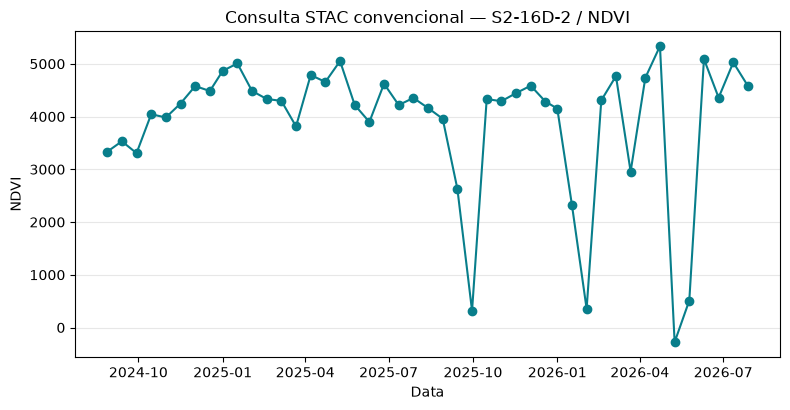

In [3]:
resultados = []
serie_final = None
for repeticao in range(1, REPETICOES + 1):
    serie, metricas = executar_consulta_convencional()
    metricas['repeticao'] = repeticao
    resultados.append(metricas)
    serie_final = serie
    print(f"Repetição {repeticao}: {metricas['tempo_total_s']:.2f}s "
          f"({metricas['cenas']} cenas; leitura dos COGs: {metricas['tempo_leitura_cogs_s']:.2f}s)")

benchmark = pd.DataFrame(resultados).set_index('repeticao')
display(benchmark.style.format({
    'tempo_busca_stac_s': '{:.3f}', 'tempo_leitura_cogs_s': '{:.3f}', 'tempo_total_s': '{:.3f}'
}))

falhas = serie_final[serie_final['erro'].notna()]
if not falhas.empty:
    display(falhas[['erro', 'tempo_cena_s']])

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(serie_final.index, serie_final['valor'], marker='o', color='#087e8b')
ax.set(title=f'Consulta STAC convencional — {COLECAO} / {VARIAVEL}', xlabel='Data', ylabel=VARIAVEL)
ax.grid(axis='y', alpha=.3)
fig.tight_layout()
plt.show()
